In [ ]:
# ============================================================
#  SiLU/Swish Activation -- CIFAR-100 Experiments
#  Paste this entire file into a single Google Colab cell,
#  OR split at each "# --- CELL X ---" comment into separate cells.
#
#  Experiments:
#    1. SiLU + No Regularization (baseline)
#    2. SiLU + Dropout
#    3. SiLU + Weight Decay
#    4. SiLU + Stochastic Depth
# ============================================================


# --- CELL 1: Installs & Imports ---

# !pip install torchinfo -q   # uncomment if not already installed


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json, os, time, copy, random
from collections import defaultdict

In [ ]:
# Reproducibility
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [ ]:
# --- CELL 2: Dataset ---

BATCH_SIZE  = 128
NUM_EPOCHS  = 75       # Change to 100 for final results
NUM_WORKERS = 2
NUM_CLASSES = 100

CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

full_train = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=train_transform)
test_set = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=test_transform)

val_size   = 5000
train_size = len(full_train) - val_size
train_set, val_set = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}")

Train: 45,000 | Val: 5,000 | Test: 10,000


In [ ]:
# --- CELL 3: Model Definition ---

class StochasticDepth(nn.Module):
    def __init__(self, survival_prob=0.8):
        super().__init__()
        self.survival_prob = survival_prob

    def forward(self, x):
        if not self.training or self.survival_prob == 1.0:
            return x
        keep = torch.bernoulli(torch.tensor(self.survival_prob)).bool()
        return x * keep.float()


class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1,
                 activation_fn=None, dropout_p=0.0, stochastic_depth_p=1.0):
        super().__init__()
        self.act = activation_fn if activation_fn is not None else nn.ReLU(inplace=True)

        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)

        self.dropout = nn.Dropout(p=dropout_p) if dropout_p > 0 else nn.Identity()
        self.sd      = StochasticDepth(stochastic_depth_p)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = self.sd(out)
        out = out + self.shortcut(x)
        out = self.act(out)
        return out


class ResNet20(nn.Module):
    def __init__(self, activation_fn=None, dropout_p=0.0,
                 stoch_depth_p=1.0, num_classes=100):
        super().__init__()
        self.act           = activation_fn if activation_fn is not None else nn.ReLU(inplace=True)
        self.dropout_p     = dropout_p
        self.stoch_depth_p = stoch_depth_p
        self.in_planes     = 16

        self.conv1  = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)
        self._init_weights()

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(BasicBlock(
                self.in_planes, planes, stride=s,
                activation_fn=self.act,
                dropout_p=self.dropout_p,
                stochastic_depth_p=self.stoch_depth_p
            ))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# Sanity check
_m = ResNet20(activation_fn=nn.SiLU()).to(DEVICE)
out = _m(torch.randn(2, 3, 32, 32).to(DEVICE))
assert out.shape == (2, 100), "Model output shape mismatch!"
print("ResNet-20 sanity check passed. Output shape:", out.shape)
del _m

ResNet-20 sanity check passed. Output shape: torch.Size([2, 100])


In [ ]:
# --- CELL 4: Sparsity Tracker ---

class SparsityTracker:
    def __init__(self, model, threshold=0.01):
        self.threshold = threshold
        self.stats     = {}
        self._hooks    = []
        for name, module in model.named_modules():
            if isinstance(module, (nn.SiLU, nn.ReLU, nn.GELU)):
                self._hooks.append(
                    module.register_forward_hook(self._make_hook(name))
                )

    def _make_hook(self, name):
        def hook(module, inp, output):
            with torch.no_grad():
                sparsity = (output.abs() < self.threshold).float().mean().item()
                self.stats.setdefault(name, []).append(sparsity)
        return hook

    def mean_sparsity(self):
        vals = [np.mean(v) for v in self.stats.values() if v]
        return float(np.mean(vals)) if vals else 0.0

    def per_layer_sparsity(self):
        return {k: float(np.mean(v)) for k, v in self.stats.items()}

    def reset(self):
        self.stats = {}

    def remove(self):
        for h in self._hooks:
            h.remove()

print("SparsityTracker defined.")


SparsityTracker defined.


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, tracker=None):
    model.eval()
    total_loss, correct_top1, correct_top5, total = 0.0, 0, 0, 0
    if tracker:
        tracker.reset()
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss   += loss.item() * imgs.size(0)
        total        += imgs.size(0)
        # Top-1
        correct_top1 += logits.argmax(1).eq(labels).sum().item()
        # Top-5
        top5_preds    = logits.topk(5, dim=1).indices
        correct_top5 += top5_preds.eq(
            labels.view(-1, 1).expand_as(top5_preds)
        ).any(dim=1).sum().item()

    sparsity = tracker.mean_sparsity() if tracker else None
    return (
        total_loss   / total,
        100.0 * correct_top1 / total,
        100.0 * correct_top5 / total,
        sparsity
    )

print("Training functions defined.")


Training functions defined.


In [ ]:
# --- CELL 6: Experiment Runner ---

def run_experiment(name, activation_fn, dropout_p=0.0,
                   weight_decay=0.0, stoch_depth_p=1.0,
                   num_epochs=NUM_EPOCHS, seed=SEED):
    set_seed(seed)
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"  dropout={dropout_p} | wd={weight_decay} | stoch_depth={stoch_depth_p}")
    print(f"{'='*60}")

    model = ResNet20(
        activation_fn=activation_fn,
        dropout_p=dropout_p,
        stoch_depth_p=stoch_depth_p,
        num_classes=NUM_CLASSES
    ).to(DEVICE)

    tracker   = SparsityTracker(model)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9,
                          weight_decay=weight_decay, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = torch.amp.GradScaler('cuda')

    history = {k: [] for k in
               ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'sparsity', 'gen_gap']}

    best_val_acc, best_weights = 0.0, None
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion,
                                          optimizer, scaler, DEVICE)
        va_loss, va_acc, sparsity = evaluate(model, val_loader, criterion,
                                             DEVICE, tracker)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        history['sparsity'].append(sparsity)
        history['gen_gap'].append(tr_acc - va_acc)

        if va_acc > best_val_acc:
            best_val_acc  = va_acc
            best_weights  = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d}/{num_epochs} | "
                  f"Train={tr_acc:.1f}% | Val={va_acc:.1f}% | "
                  f"Gap={tr_acc - va_acc:.1f}% | "
                  f"Sparsity={sparsity:.4f} | "
                  f"Time={time.time()-t0:.0f}s")

    # Evaluate best checkpoint on test set
    model.load_state_dict(best_weights)
    _, test_acc, test_sparsity = evaluate(model, test_loader, criterion, DEVICE, tracker)
    per_layer = tracker.per_layer_sparsity()
    tracker.remove()

    print(f"\n  Best Val Acc : {best_val_acc:.2f}%")
    print(f"  Test Acc     : {test_acc:.2f}%")
    print(f"  Avg Sparsity : {test_sparsity:.4f}")
    print(f"  Gen Gap      : {history['gen_gap'][-1]:.2f}%")

    return {
        'name':               name,
        'history':            history,
        'best_val_acc':       best_val_acc,
        'test_acc':           test_acc,
        'final_gen_gap':      history['gen_gap'][-1],
        'mean_sparsity':      test_sparsity,
        'per_layer_sparsity': per_layer,
    }

print("run_experiment() defined.")

run_experiment() defined.


In [ ]:
# ============================================================
#  CELL 7a: EXPERIMENT 1 — SiLU + No Regularization (Baseline)
# ============================================================

set_seed(42)
NUM_EPOCHS = 100

model_1 = ResNet20(
    activation_fn = nn.SiLU(),
    dropout_p     = 0.0,
    stoch_depth_p = 1.0,
    num_classes   = 100
).to(DEVICE)

tracker_1   = SparsityTracker(model_1)
criterion_1 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_1 = optim.SGD(model_1.parameters(), lr=0.1, momentum=0.9,
                        weight_decay=0.0, nesterov=True)
scheduler_1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_1, T_max=NUM_EPOCHS)
scaler_1    = torch.amp.GradScaler('cuda')

history_1 = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'val_top5':   [], 'sparsity':  [],
    'gen_gap':    [],
}

best_val_acc_1 = 0.0
best_weights_1 = None
t0 = time.time()

print("=" * 65)
print("  EXPERIMENT 1: SiLU + No Regularization (Baseline)")
print("  dropout=0.0 | wd=0.0 | stoch_depth=1.0")
print("=" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model_1, train_loader, criterion_1, optimizer_1, scaler_1, DEVICE)
    va_loss, va_acc, va_top5, sparsity = evaluate(
        model_1, val_loader, criterion_1, DEVICE, tracker_1)
    scheduler_1.step()

    history_1['train_loss'].append(tr_loss)
    history_1['train_acc'].append(tr_acc)
    history_1['val_loss'].append(va_loss)
    history_1['val_acc'].append(va_acc)
    history_1['val_top5'].append(va_top5)
    history_1['sparsity'].append(sparsity)
    history_1['gen_gap'].append(tr_acc - va_acc)

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_weights_1 = copy.deepcopy(model_1.state_dict())

    print(f"  Ep {epoch:3d}/{NUM_EPOCHS} | "
          f"Train={tr_acc:.1f}% | Val={va_acc:.1f}% | "
          f"Top5={va_top5:.1f}% | "
          f"Gap={tr_acc - va_acc:.1f}% | "
          f"Sparsity={sparsity:.4f} | "
          f"Time={time.time()-t0:.0f}s")

model_1.load_state_dict(best_weights_1)
_, test_acc_1, test_top5_1, test_sparsity_1 = evaluate(
    model_1, test_loader, criterion_1, DEVICE, tracker_1)
tracker_1.remove()

print(f"\n  Best Val Acc (Top-1) : {best_val_acc_1:.2f}%")
print(f"  Test Acc     (Top-1) : {test_acc_1:.2f}%")
print(f"  Test Acc     (Top-5) : {test_top5_1:.2f}%")
print(f"  Avg Sparsity         : {test_sparsity_1:.4f}")
print(f"  Final Gen Gap        : {history_1['gen_gap'][-1]:.2f}%")

result_1 = {
    'name':          'SiLU + No Reg (Baseline)',
    'history':        history_1,
    'best_val_acc':   best_val_acc_1,
    'test_acc':       test_acc_1,
    'test_acc_top5':  test_top5_1,
    'final_gen_gap':  history_1['gen_gap'][-1],
    'mean_sparsity':  test_sparsity_1,
}
print("\nExperiment 1 complete! Stored in result_1")

  EXPERIMENT 1: SiLU + No Regularization (Baseline)
  dropout=0.0 | wd=0.0 | stoch_depth=1.0
  Ep   1/100 | Train=8.0% | Val=12.8% | Top5=35.8% | Gap=-4.9% | Sparsity=0.0160 | Time=36s
  Ep   2/100 | Train=18.8% | Val=18.6% | Top5=47.8% | Gap=0.2% | Sparsity=0.0151 | Time=71s
  Ep   3/100 | Train=27.1% | Val=24.9% | Top5=55.2% | Gap=2.3% | Sparsity=0.0143 | Time=110s
  Ep   4/100 | Train=33.7% | Val=35.0% | Top5=66.4% | Gap=-1.3% | Sparsity=0.0139 | Time=146s
  Ep   5/100 | Train=39.0% | Val=39.7% | Top5=70.8% | Gap=-0.7% | Sparsity=0.0138 | Time=182s
  Ep   6/100 | Train=42.9% | Val=41.5% | Top5=73.0% | Gap=1.4% | Sparsity=0.0132 | Time=217s
  Ep   7/100 | Train=46.2% | Val=44.0% | Top5=75.6% | Gap=2.2% | Sparsity=0.0130 | Time=252s
  Ep   8/100 | Train=48.6% | Val=46.5% | Top5=76.5% | Gap=2.1% | Sparsity=0.0129 | Time=288s
  Ep   9/100 | Train=51.1% | Val=48.5% | Top5=79.0% | Gap=2.6% | Sparsity=0.0126 | Time=323s
  Ep  10/100 | Train=52.7% | Val=50.1% | Top5=79.4% | Gap=2.6% | Spars

In [ ]:
# ============================================================
#  CELL 7b: EXPERIMENT 2 — SiLU + Dropout
# ============================================================

set_seed(42)

model_2 = ResNet20(
    activation_fn = nn.SiLU(),
    dropout_p     = 0.3,
    stoch_depth_p = 1.0,
    num_classes   = 100
).to(DEVICE)

tracker_2   = SparsityTracker(model_2)
criterion_2 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_2 = optim.SGD(model_2.parameters(), lr=0.1, momentum=0.9,
                        weight_decay=0.0, nesterov=True)
scheduler_2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_2, T_max=NUM_EPOCHS)
scaler_2    = torch.amp.GradScaler('cuda')

history_2 = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'val_top5':   [], 'sparsity':  [],
    'gen_gap':    [],
}

best_val_acc_2 = 0.0
best_weights_2 = None
t0 = time.time()

print("=" * 65)
print("  EXPERIMENT 2: SiLU + Dropout")
print("  dropout=0.3 | wd=0.0 | stoch_depth=1.0")
print("=" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model_2, train_loader, criterion_2, optimizer_2, scaler_2, DEVICE)
    va_loss, va_acc, va_top5, sparsity = evaluate(
        model_2, val_loader, criterion_2, DEVICE, tracker_2)
    scheduler_2.step()

    history_2['train_loss'].append(tr_loss)
    history_2['train_acc'].append(tr_acc)
    history_2['val_loss'].append(va_loss)
    history_2['val_acc'].append(va_acc)
    history_2['val_top5'].append(va_top5)
    history_2['sparsity'].append(sparsity)
    history_2['gen_gap'].append(tr_acc - va_acc)

    if va_acc > best_val_acc_2:
        best_val_acc_2 = va_acc
        best_weights_2 = copy.deepcopy(model_2.state_dict())

    print(f"  Ep {epoch:3d}/{NUM_EPOCHS} | "
          f"Train={tr_acc:.1f}% | Val={va_acc:.1f}% | "
          f"Top5={va_top5:.1f}% | "
          f"Gap={tr_acc - va_acc:.1f}% | "
          f"Sparsity={sparsity:.4f} | "
          f"Time={time.time()-t0:.0f}s")

model_2.load_state_dict(best_weights_2)
_, test_acc_2, test_top5_2, test_sparsity_2 = evaluate(
    model_2, test_loader, criterion_2, DEVICE, tracker_2)
tracker_2.remove()

print(f"\n  Best Val Acc (Top-1) : {best_val_acc_2:.2f}%")
print(f"  Test Acc     (Top-1) : {test_acc_2:.2f}%")
print(f"  Test Acc     (Top-5) : {test_top5_2:.2f}%")
print(f"  Avg Sparsity         : {test_sparsity_2:.4f}")
print(f"  Final Gen Gap        : {history_2['gen_gap'][-1]:.2f}%")

result_2 = {
    'name':          'SiLU + Dropout',
    'history':        history_2,
    'best_val_acc':   best_val_acc_2,
    'test_acc':       test_acc_2,
    'test_acc_top5':  test_top5_2,
    'final_gen_gap':  history_2['gen_gap'][-1],
    'mean_sparsity':  test_sparsity_2,
}
print("\nExperiment 2 complete! Stored in result_2")

  EXPERIMENT 2: SiLU + Dropout
  dropout=0.3 | wd=0.0 | stoch_depth=1.0
  Ep   1/100 | Train=6.0% | Val=10.7% | Top5=32.9% | Gap=-4.7% | Sparsity=0.0171 | Time=36s
  Ep   2/100 | Train=14.5% | Val=16.3% | Top5=44.4% | Gap=-1.9% | Sparsity=0.0156 | Time=73s
  Ep   3/100 | Train=21.2% | Val=25.2% | Top5=55.9% | Gap=-4.0% | Sparsity=0.0152 | Time=108s
  Ep   4/100 | Train=26.9% | Val=29.8% | Top5=61.5% | Gap=-2.9% | Sparsity=0.0146 | Time=144s
  Ep   5/100 | Train=32.1% | Val=34.8% | Top5=66.0% | Gap=-2.7% | Sparsity=0.0145 | Time=181s
  Ep   6/100 | Train=36.1% | Val=39.2% | Top5=70.7% | Gap=-3.1% | Sparsity=0.0139 | Time=217s
  Ep   7/100 | Train=39.5% | Val=39.9% | Top5=73.1% | Gap=-0.4% | Sparsity=0.0140 | Time=252s
  Ep   8/100 | Train=42.4% | Val=43.8% | Top5=74.4% | Gap=-1.4% | Sparsity=0.0137 | Time=288s
  Ep   9/100 | Train=44.7% | Val=44.9% | Top5=75.5% | Gap=-0.3% | Sparsity=0.0139 | Time=324s
  Ep  10/100 | Train=46.4% | Val=47.5% | Top5=77.5% | Gap=-1.1% | Sparsity=0.0136 | T

In [ ]:
# ============================================================
#  CELL 7c: EXPERIMENT 3 — SiLU + Weight Decay
# ============================================================

set_seed(42)

model_3 = ResNet20(
    activation_fn = nn.SiLU(),
    dropout_p     = 0.0,
    stoch_depth_p = 1.0,
    num_classes   = 100
).to(DEVICE)

tracker_3   = SparsityTracker(model_3)
criterion_3 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_3 = optim.SGD(model_3.parameters(), lr=0.1, momentum=0.9,
                        weight_decay=5e-4, nesterov=True)
scheduler_3 = optim.lr_scheduler.CosineAnnealingLR(optimizer_3, T_max=NUM_EPOCHS)
scaler_3    = torch.amp.GradScaler('cuda')

history_3 = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'val_top5':   [], 'sparsity':  [],
    'gen_gap':    [],
}

best_val_acc_3 = 0.0
best_weights_3 = None
t0 = time.time()

print("=" * 65)
print("  EXPERIMENT 3: SiLU + Weight Decay")
print("  dropout=0.0 | wd=5e-4 | stoch_depth=1.0")
print("=" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model_3, train_loader, criterion_3, optimizer_3, scaler_3, DEVICE)
    va_loss, va_acc, va_top5, sparsity = evaluate(
        model_3, val_loader, criterion_3, DEVICE, tracker_3)
    scheduler_3.step()

    history_3['train_loss'].append(tr_loss)
    history_3['train_acc'].append(tr_acc)
    history_3['val_loss'].append(va_loss)
    history_3['val_acc'].append(va_acc)
    history_3['val_top5'].append(va_top5)
    history_3['sparsity'].append(sparsity)
    history_3['gen_gap'].append(tr_acc - va_acc)

    if va_acc > best_val_acc_3:
        best_val_acc_3 = va_acc
        best_weights_3 = copy.deepcopy(model_3.state_dict())

    print(f"  Ep {epoch:3d}/{NUM_EPOCHS} | "
          f"Train={tr_acc:.1f}% | Val={va_acc:.1f}% | "
          f"Top5={va_top5:.1f}% | "
          f"Gap={tr_acc - va_acc:.1f}% | "
          f"Sparsity={sparsity:.4f} | "
          f"Time={time.time()-t0:.0f}s")

model_3.load_state_dict(best_weights_3)
_, test_acc_3, test_top5_3, test_sparsity_3 = evaluate(
    model_3, test_loader, criterion_3, DEVICE, tracker_3)
tracker_3.remove()

print(f"\n  Best Val Acc (Top-1) : {best_val_acc_3:.2f}%")
print(f"  Test Acc     (Top-1) : {test_acc_3:.2f}%")
print(f"  Test Acc     (Top-5) : {test_top5_3:.2f}%")
print(f"  Avg Sparsity         : {test_sparsity_3:.4f}")
print(f"  Final Gen Gap        : {history_3['gen_gap'][-1]:.2f}%")

result_3 = {
    'name':          'SiLU + Weight Decay',
    'history':        history_3,
    'best_val_acc':   best_val_acc_3,
    'test_acc':       test_acc_3,
    'test_acc_top5':  test_top5_3,
    'final_gen_gap':  history_3['gen_gap'][-1],
    'mean_sparsity':  test_sparsity_3,
}
print("\nExperiment 3 complete! Stored in result_3")

  EXPERIMENT 3: SiLU + Weight Decay
  dropout=0.0 | wd=5e-4 | stoch_depth=1.0
  Ep   1/100 | Train=7.7% | Val=12.0% | Top5=37.2% | Gap=-4.3% | Sparsity=0.0194 | Time=35s
  Ep   2/100 | Train=17.5% | Val=18.1% | Top5=47.5% | Gap=-0.6% | Sparsity=0.0203 | Time=70s
  Ep   3/100 | Train=25.7% | Val=26.4% | Top5=56.6% | Gap=-0.7% | Sparsity=0.0216 | Time=106s
  Ep   4/100 | Train=31.6% | Val=32.5% | Top5=63.5% | Gap=-0.9% | Sparsity=0.0220 | Time=143s
  Ep   5/100 | Train=36.1% | Val=34.6% | Top5=66.3% | Gap=1.5% | Sparsity=0.0224 | Time=179s
  Ep   6/100 | Train=39.9% | Val=36.6% | Top5=69.4% | Gap=3.3% | Sparsity=0.0226 | Time=216s
  Ep   7/100 | Train=42.6% | Val=38.0% | Top5=70.7% | Gap=4.6% | Sparsity=0.0222 | Time=252s
  Ep   8/100 | Train=44.6% | Val=42.4% | Top5=74.8% | Gap=2.2% | Sparsity=0.0222 | Time=288s
  Ep   9/100 | Train=46.5% | Val=42.0% | Top5=74.2% | Gap=4.5% | Sparsity=0.0216 | Time=323s
  Ep  10/100 | Train=47.6% | Val=45.2% | Top5=76.9% | Gap=2.4% | Sparsity=0.0221 | T

In [ ]:
# ============================================================
#  CELL 7d: EXPERIMENT 4 — SiLU + Stochastic Depth
# ============================================================

set_seed(42)

model_4 = ResNet20(
    activation_fn = nn.SiLU(),
    dropout_p     = 0.0,
    stoch_depth_p = 0.8,
    num_classes   = 100
).to(DEVICE)

tracker_4   = SparsityTracker(model_4)
criterion_4 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_4 = optim.SGD(model_4.parameters(), lr=0.1, momentum=0.9,
                        weight_decay=0.0, nesterov=True)
scheduler_4 = optim.lr_scheduler.CosineAnnealingLR(optimizer_4, T_max=NUM_EPOCHS)
scaler_4    = torch.amp.GradScaler('cuda')

history_4 = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'val_top5':   [], 'sparsity':  [],
    'gen_gap':    [],
}

best_val_acc_4 = 0.0
best_weights_4 = None
t0 = time.time()

print("=" * 65)
print("  EXPERIMENT 4: SiLU + Stochastic Depth")
print("  dropout=0.0 | wd=0.0 | stoch_depth=0.8")
print("=" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model_4, train_loader, criterion_4, optimizer_4, scaler_4, DEVICE)
    va_loss, va_acc, va_top5, sparsity = evaluate(
        model_4, val_loader, criterion_4, DEVICE, tracker_4)
    scheduler_4.step()

    history_4['train_loss'].append(tr_loss)
    history_4['train_acc'].append(tr_acc)
    history_4['val_loss'].append(va_loss)
    history_4['val_acc'].append(va_acc)
    history_4['val_top5'].append(va_top5)
    history_4['sparsity'].append(sparsity)
    history_4['gen_gap'].append(tr_acc - va_acc)

    if va_acc > best_val_acc_4:
        best_val_acc_4 = va_acc
        best_weights_4 = copy.deepcopy(model_4.state_dict())

    print(f"  Ep {epoch:3d}/{NUM_EPOCHS} | "
          f"Train={tr_acc:.1f}% | Val={va_acc:.1f}% | "
          f"Top5={va_top5:.1f}% | "
          f"Gap={tr_acc - va_acc:.1f}% | "
          f"Sparsity={sparsity:.4f} | "
          f"Time={time.time()-t0:.0f}s")

model_4.load_state_dict(best_weights_4)
_, test_acc_4, test_top5_4, test_sparsity_4 = evaluate(
    model_4, test_loader, criterion_4, DEVICE, tracker_4)
tracker_4.remove()

print(f"\n  Best Val Acc (Top-1) : {best_val_acc_4:.2f}%")
print(f"  Test Acc     (Top-1) : {test_acc_4:.2f}%")
print(f"  Test Acc     (Top-5) : {test_top5_4:.2f}%")
print(f"  Avg Sparsity         : {test_sparsity_4:.4f}")
print(f"  Final Gen Gap        : {history_4['gen_gap'][-1]:.2f}%")

result_4 = {
    'name':          'SiLU + Stochastic Depth',
    'history':        history_4,
    'best_val_acc':   best_val_acc_4,
    'test_acc':       test_acc_4,
    'test_acc_top5':  test_top5_4,
    'final_gen_gap':  history_4['gen_gap'][-1],
    'mean_sparsity':  test_sparsity_4,
}
print("\nExperiment 4 complete! Stored in result_4")

  EXPERIMENT 4: SiLU + Stochastic Depth
  dropout=0.0 | wd=0.0 | stoch_depth=0.8
  Ep   1/100 | Train=5.6% | Val=7.6% | Top5=26.0% | Gap=-2.1% | Sparsity=0.0149 | Time=35s
  Ep   2/100 | Train=12.8% | Val=12.4% | Top5=35.0% | Gap=0.4% | Sparsity=0.0141 | Time=71s
  Ep   3/100 | Train=18.4% | Val=20.0% | Top5=46.5% | Gap=-1.6% | Sparsity=0.0137 | Time=107s
  Ep   4/100 | Train=23.1% | Val=21.1% | Top5=49.6% | Gap=1.9% | Sparsity=0.0130 | Time=142s
  Ep   5/100 | Train=27.9% | Val=24.0% | Top5=52.7% | Gap=3.8% | Sparsity=0.0128 | Time=178s
  Ep   6/100 | Train=32.0% | Val=29.5% | Top5=60.2% | Gap=2.5% | Sparsity=0.0130 | Time=215s
  Ep   7/100 | Train=35.1% | Val=31.9% | Top5=61.9% | Gap=3.1% | Sparsity=0.0130 | Time=251s
  Ep   8/100 | Train=37.0% | Val=38.2% | Top5=68.1% | Gap=-1.1% | Sparsity=0.0128 | Time=287s
  Ep   9/100 | Train=39.7% | Val=38.6% | Top5=69.1% | Gap=1.1% | Sparsity=0.0132 | Time=323s
  Ep  10/100 | Train=41.4% | Val=33.6% | Top5=64.8% | Gap=7.9% | Sparsity=0.0135 | 

In [ ]:
# ============================================================
#  CELL 7e: COMBINE ALL RESULTS
#  Run after all 4 experiments finish
# ============================================================

all_results = {
    'SiLU_None':        result_1,
    'SiLU_Dropout':     result_2,
    'SiLU_WeightDecay': result_3,
    'SiLU_StochDepth':  result_4,
}

print("\n" + "=" * 78)
print("  ALL EXPERIMENTS COMPLETE — FINAL SUMMARY")
print("=" * 78)
print(f"  {'Experiment':<30} | {'Val Top-1':>9} | {'Test Top-1':>10} | {'Test Top-5':>10} | {'Gap':>7} | {'Sparsity':>9}")
print("-" * 78)
for key, res in all_results.items():
    print(f"  {res['name']:<30} | "
          f"{res['best_val_acc']:>8.2f}% | "
          f"{res['test_acc']:>9.2f}% | "
          f"{res['test_acc_top5']:>9.2f}% | "
          f"{res['final_gen_gap']:>6.2f}% | "
          f"{res['mean_sparsity']:>9.4f}")
print("=" * 78)
print("\nall_results ready — run Cell 8 for plots!")


  ALL EXPERIMENTS COMPLETE — FINAL SUMMARY
  Experiment                     | Val Top-1 | Test Top-1 | Test Top-5 |     Gap |  Sparsity
------------------------------------------------------------------------------
  SiLU + No Reg (Baseline)       |    63.20% |     63.82% |     86.91% |  24.88% |    0.0129
  SiLU + Dropout                 |    64.68% |     65.66% |     89.59% |   7.54% |    0.0146
  SiLU + Weight Decay            |    67.32% |     68.54% |     90.56% |  19.10% |    0.0228
  SiLU + Stochastic Depth        |    58.86% |     58.91% |     85.09% |  11.54% |    0.0187

all_results ready — run Cell 8 for plots!


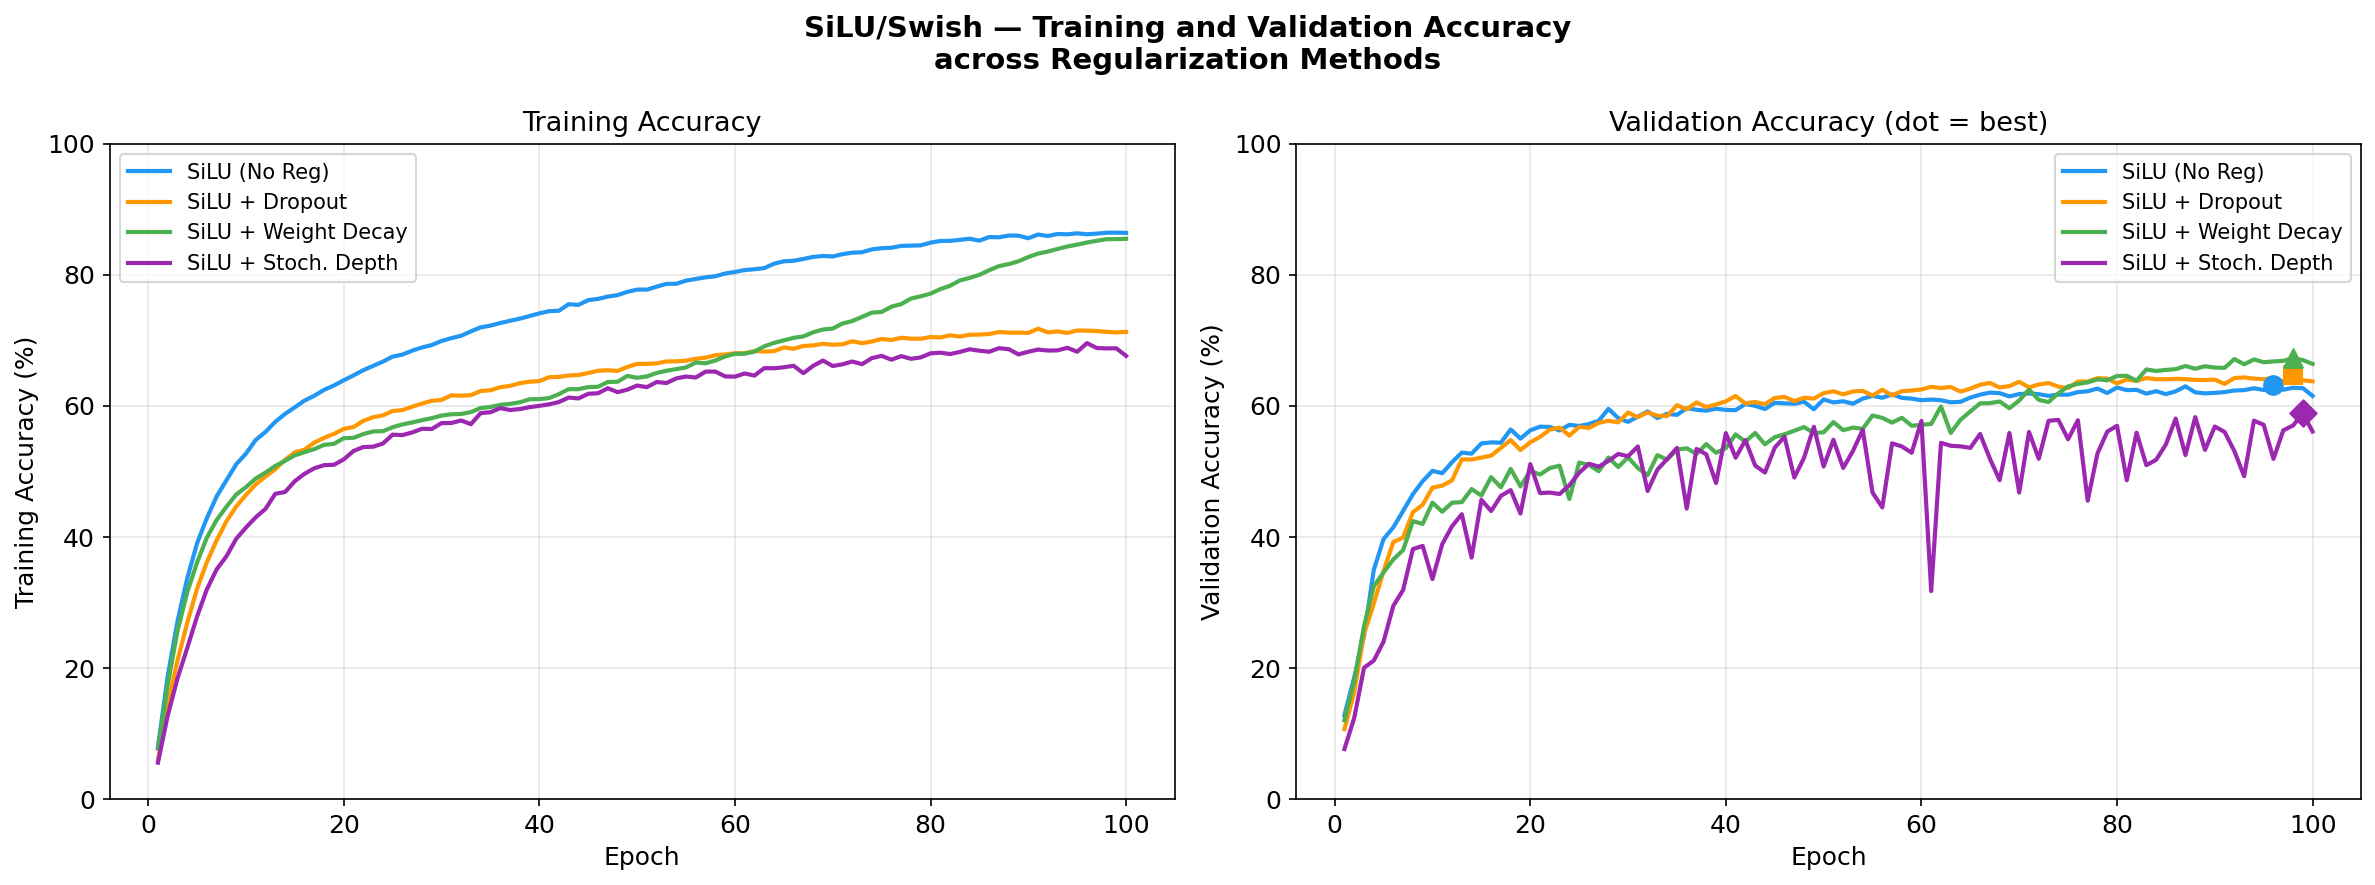

Plot 1 saved: plot1_accuracy_curves.png


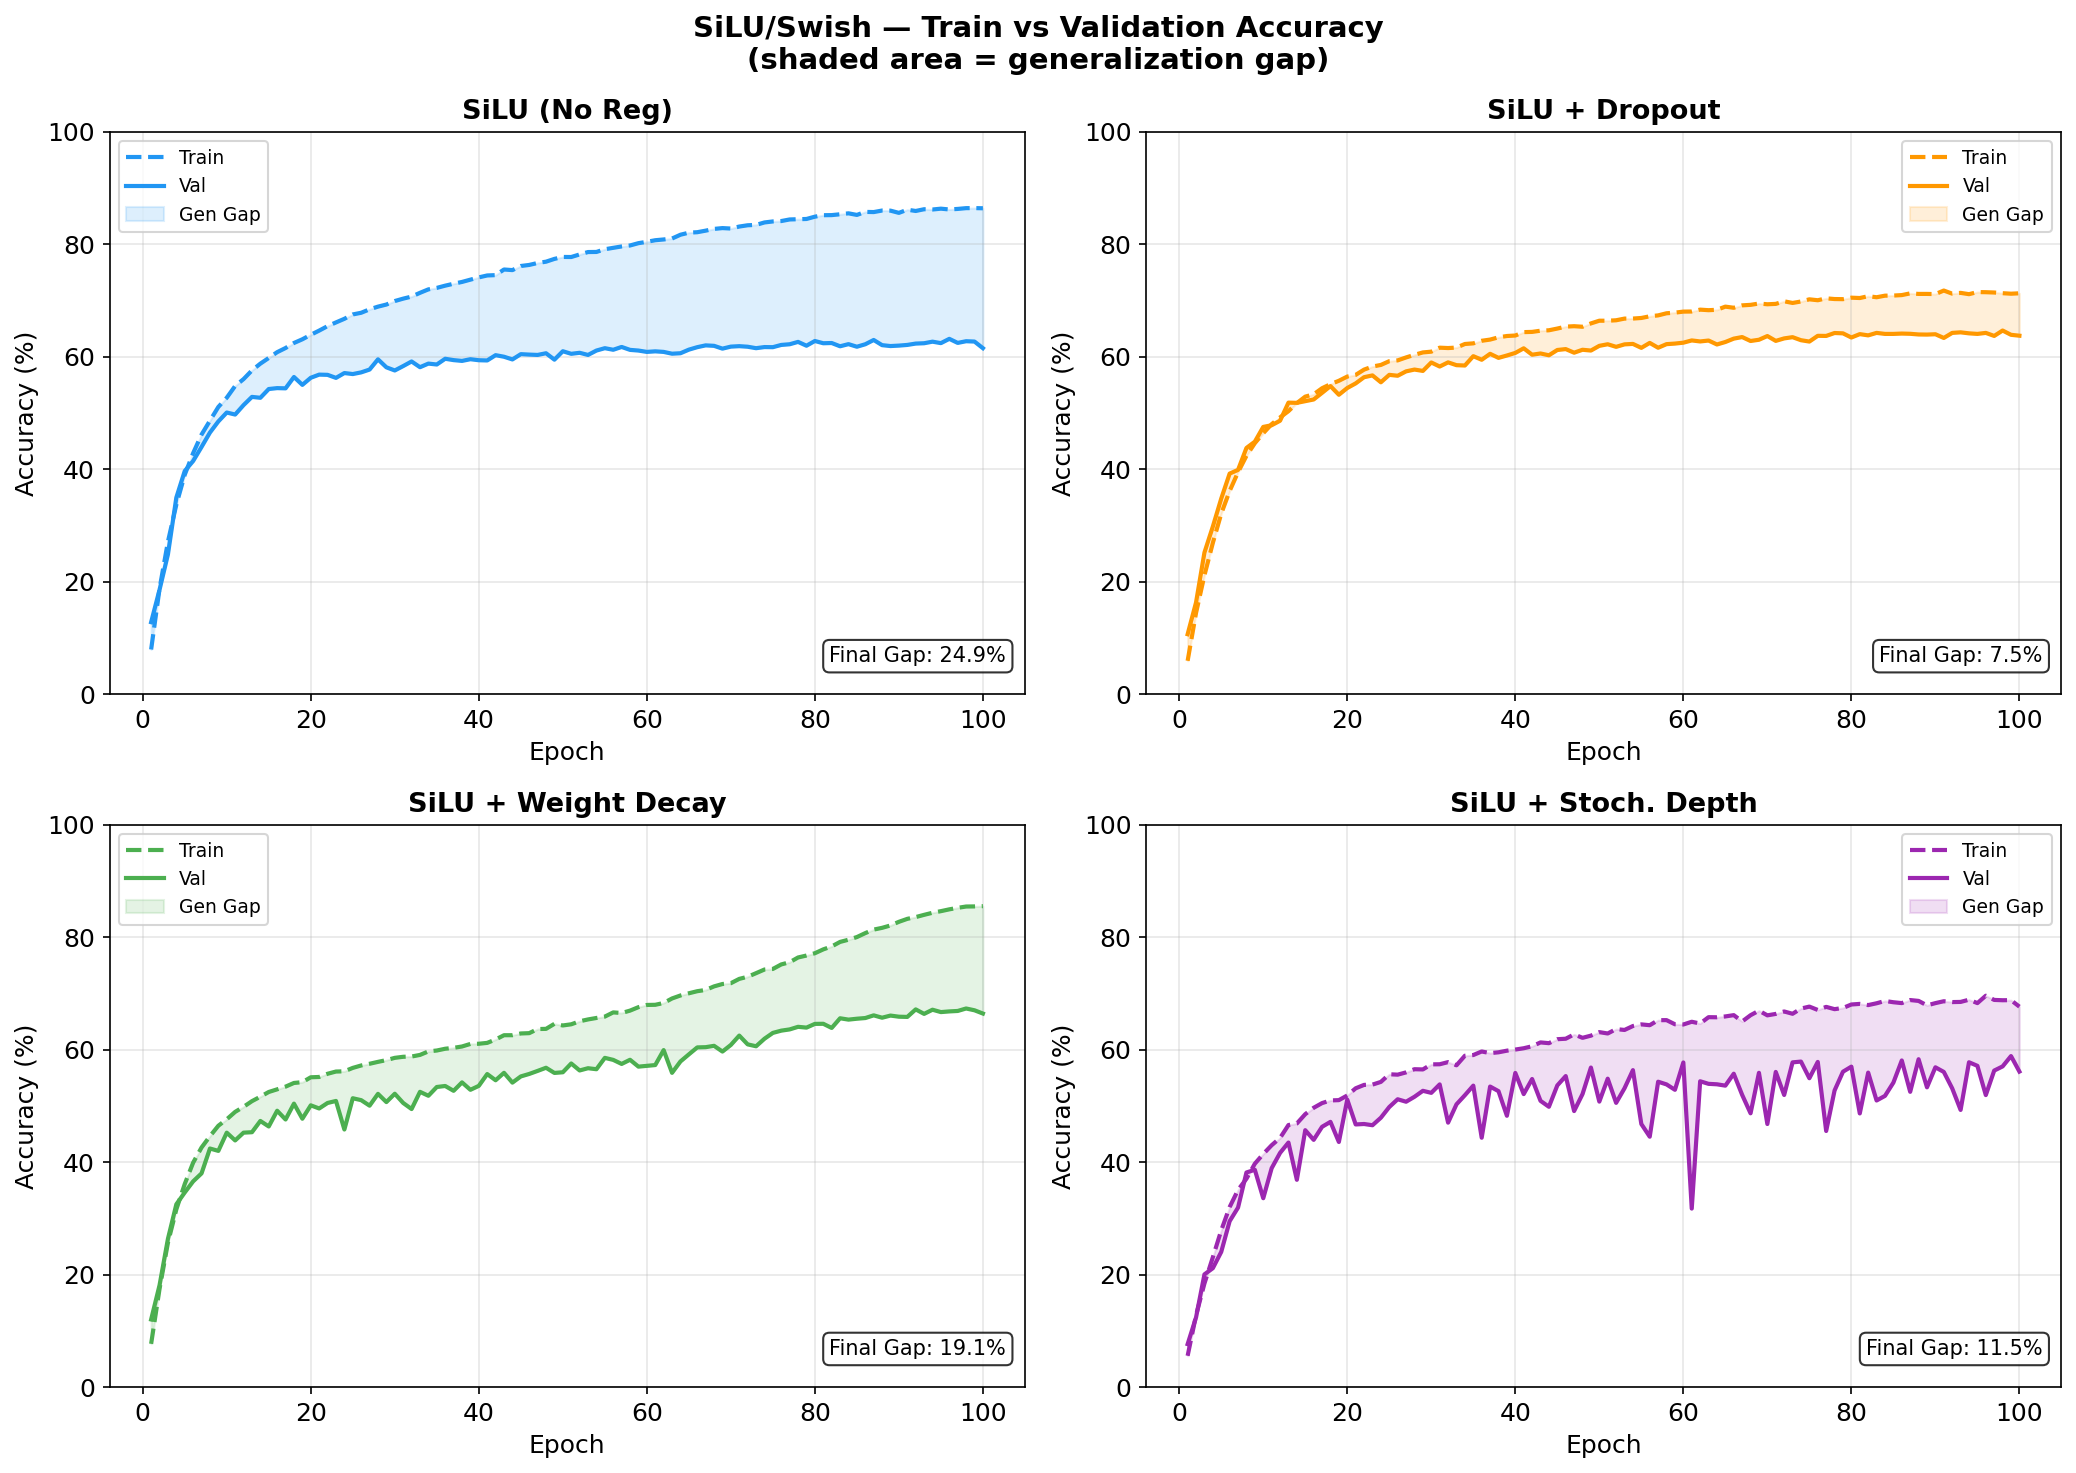

Plot 2 saved: plot2_train_vs_val.png


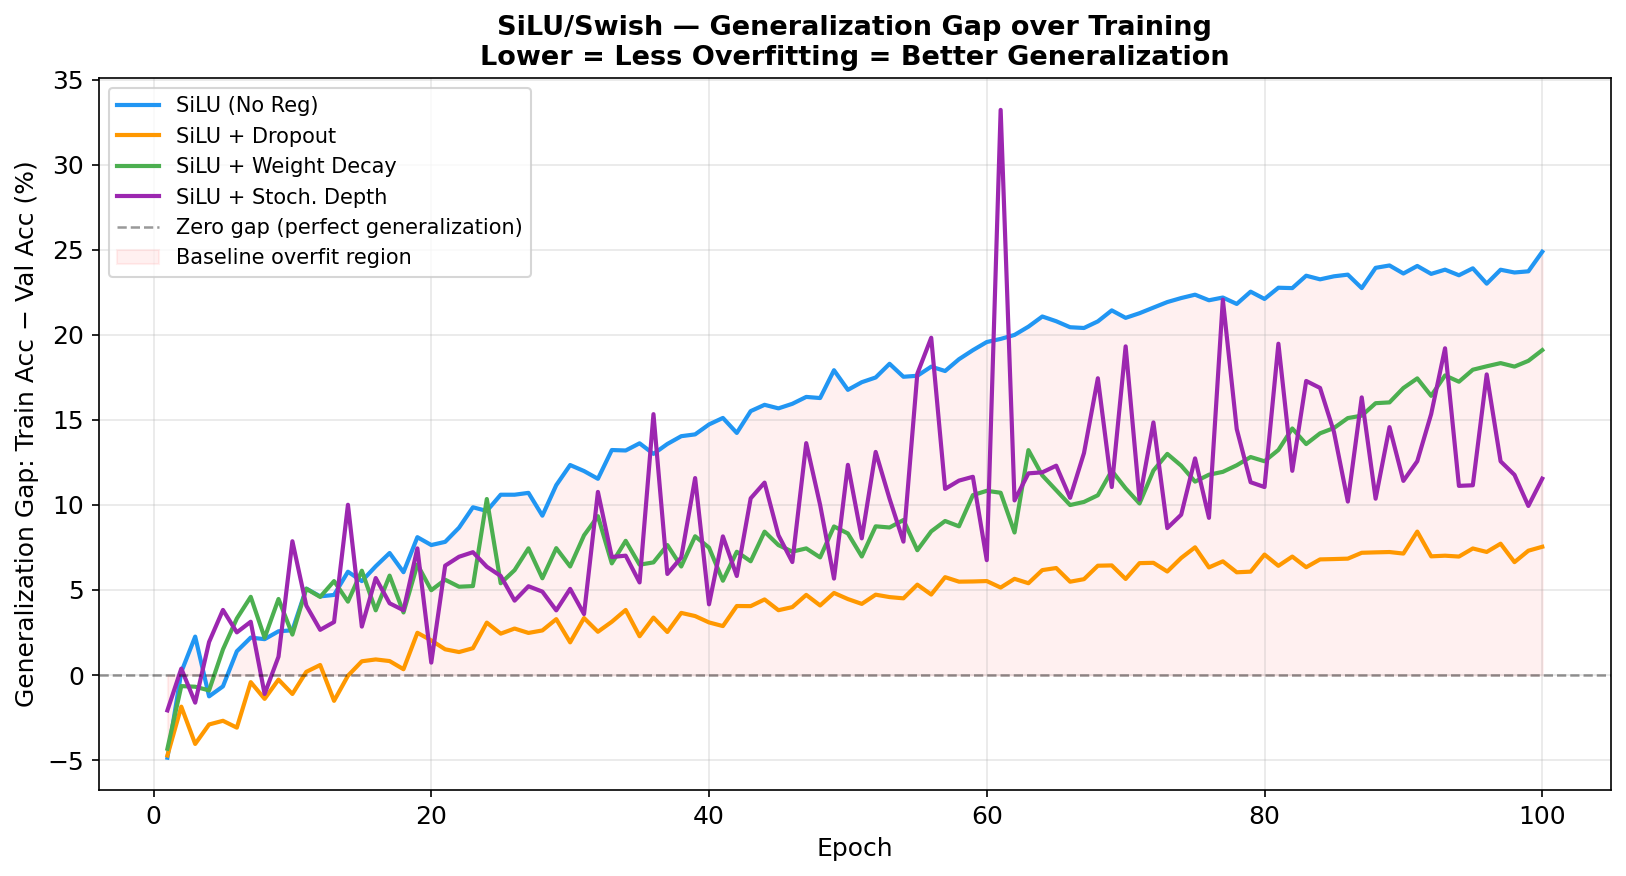

Plot 3 saved: plot3_gen_gap.png


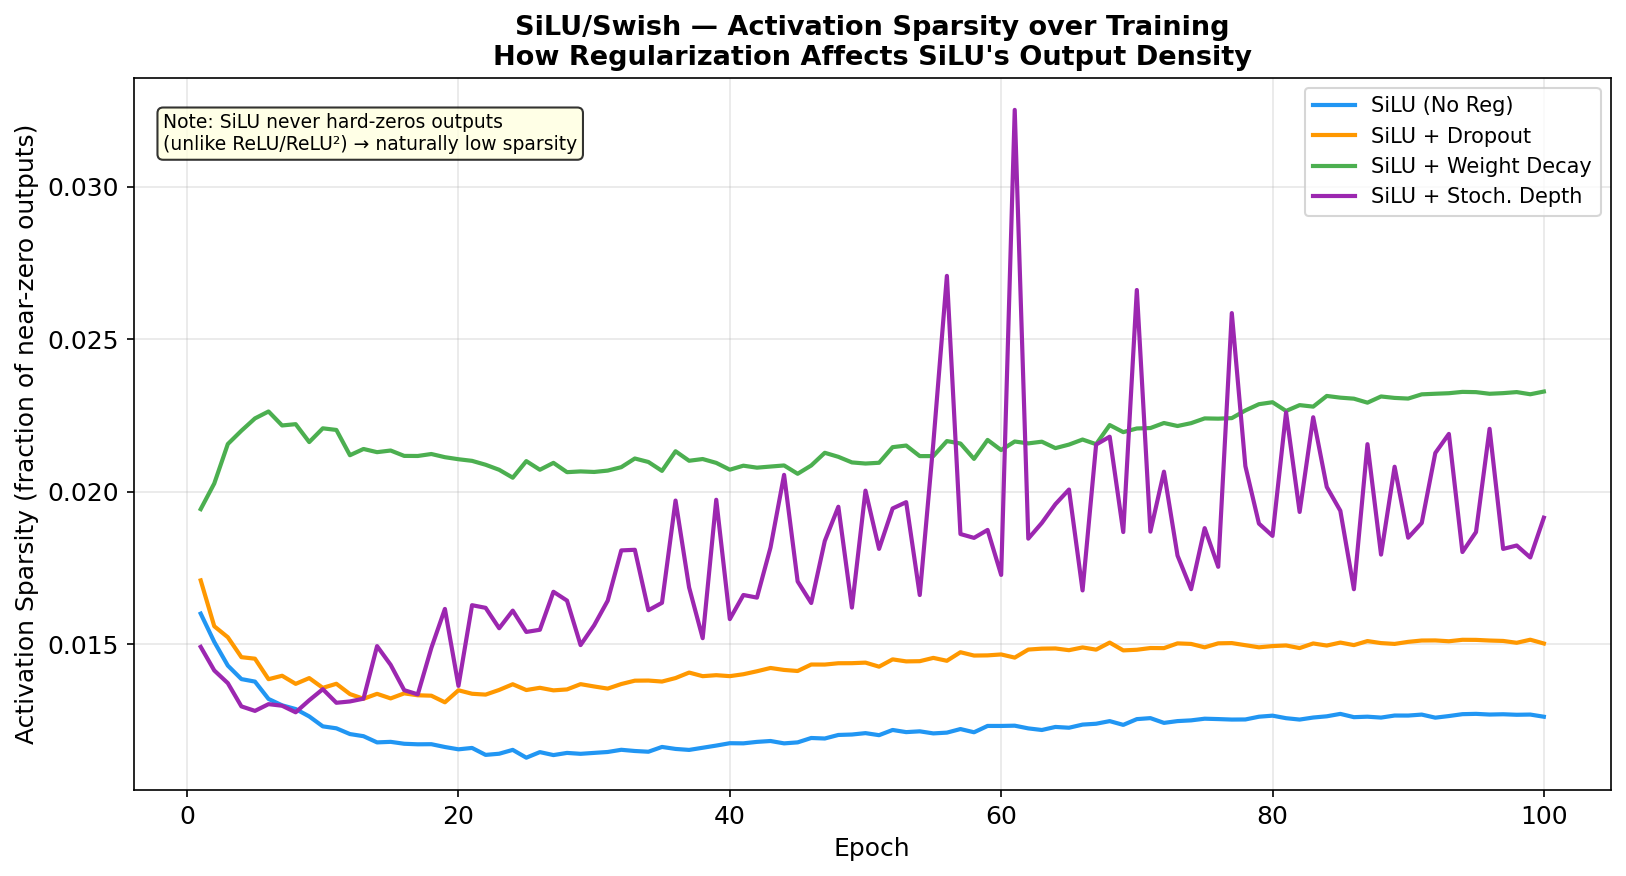

Plot 4 saved: plot4_sparsity.png


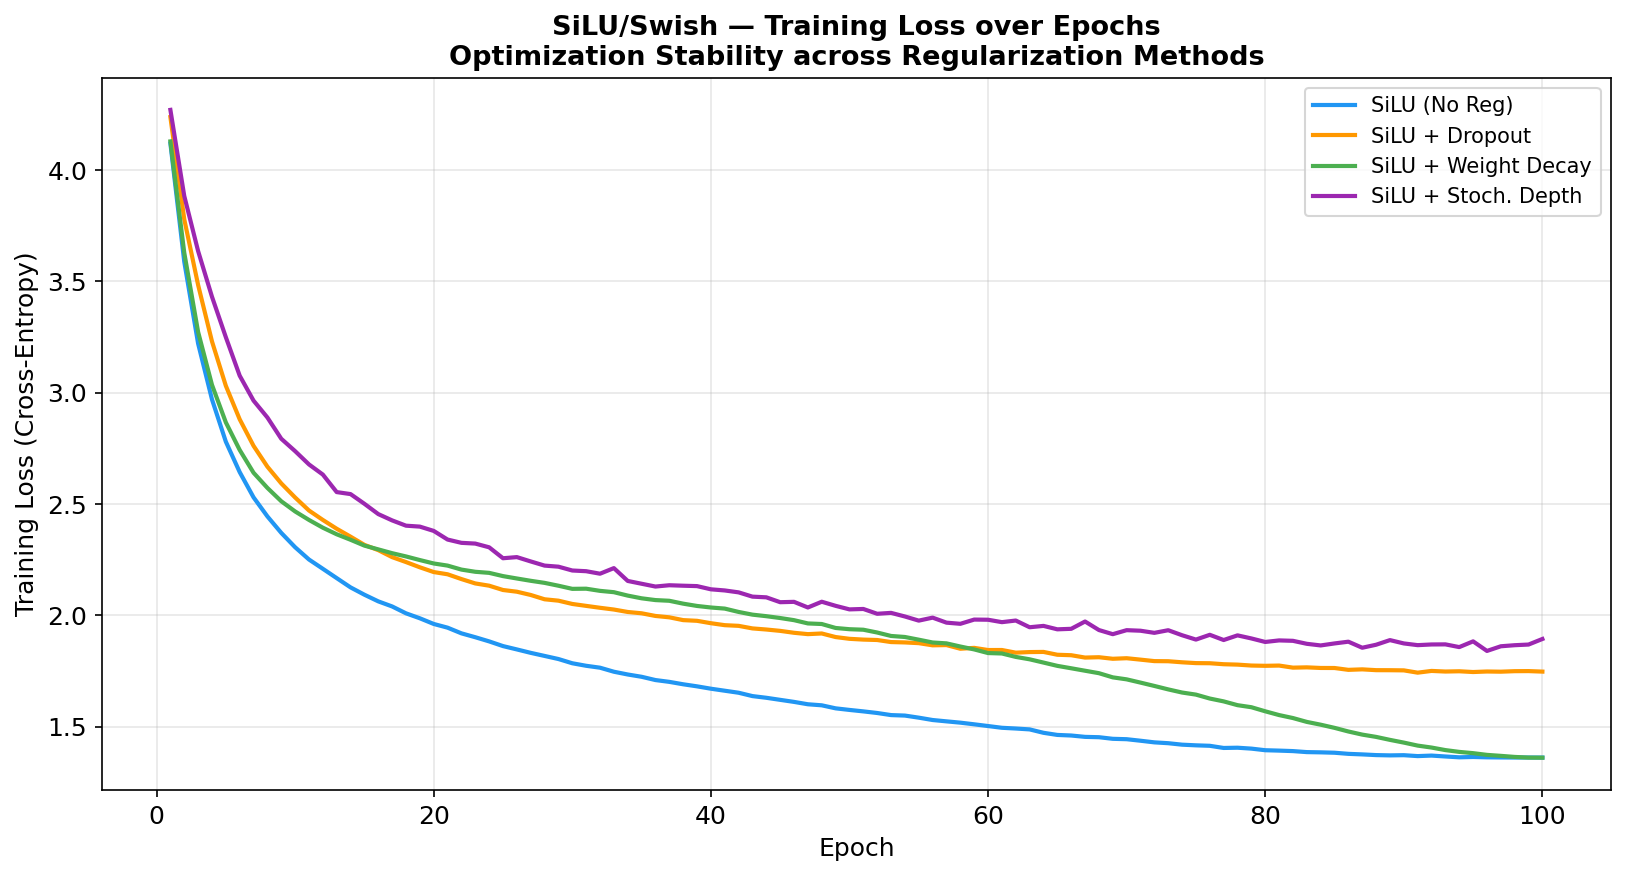

Plot 5 saved: plot5_train_loss.png


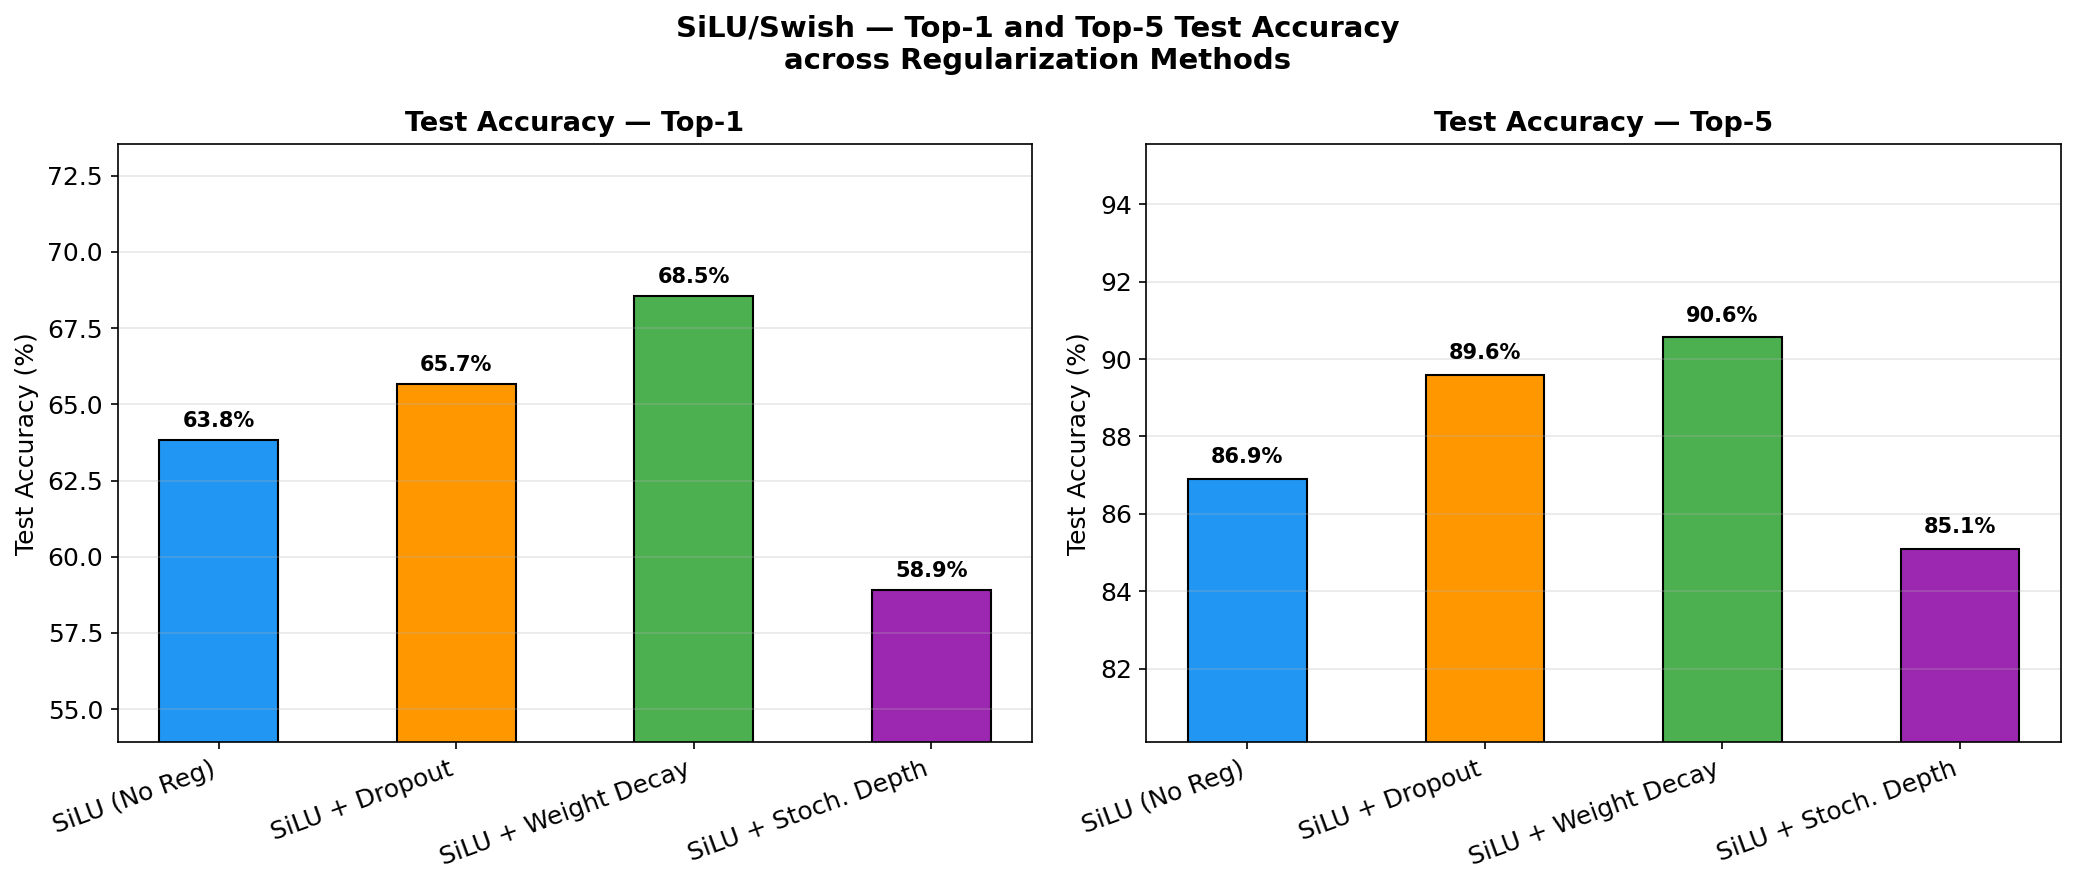

Plot 6 saved: plot6_top1_top5.png


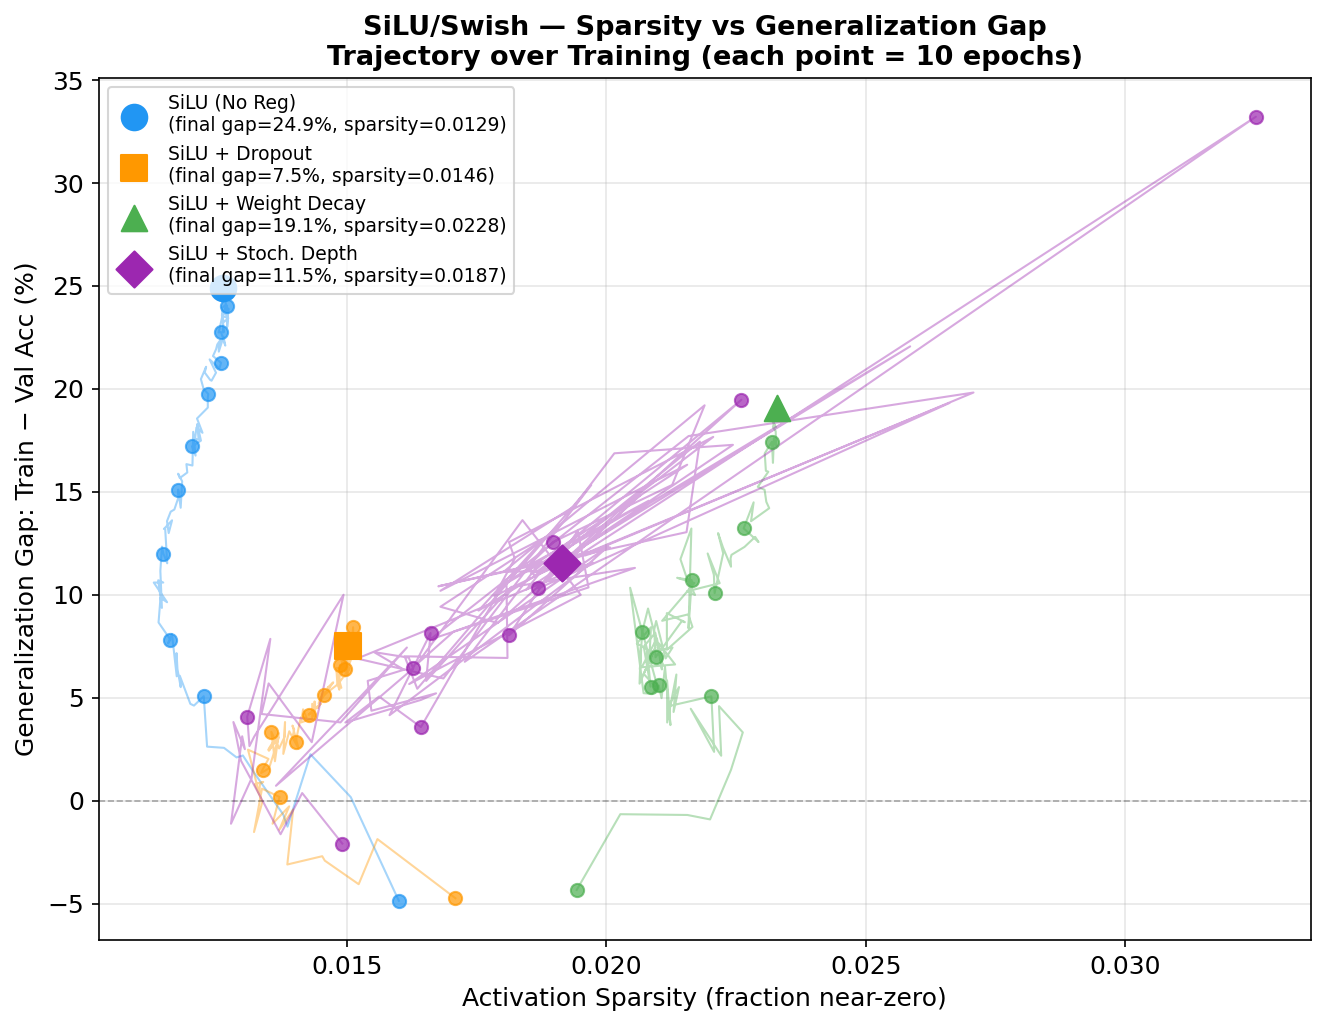

Plot 7 saved: plot7_sparsity_vs_gap.png

  RESULTS SUMMARY TABLE
              Experiment  Best Val Acc (%)  Test Top-1 (%)  Test Top-5 (%)  Final Gap (%)  Avg Sparsity
     SiLU + Weight Decay             67.32           68.54           90.56          19.10        0.0228
          SiLU + Dropout             64.68           65.66           89.59           7.54        0.0146
SiLU + No Reg (Baseline)             63.20           63.82           86.91          24.88        0.0129
 SiLU + Stochastic Depth             58.86           58.91           85.09          11.54        0.0187

Saved: silu_results_summary.csv


ValueError: mount failed

In [ ]:
# ============================================================
#  RESEARCH PLOTS — SiLU/Swish Activation Experiments
#  Run this cell AFTER all 4 experiments finish (after Cell 7e)
#  Generates 7 publication-quality plots
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import json

# ── Plot Settings ─────────────────────────────────────────────────────────────
COLORS = {
    'SiLU_None':        '#2196F3',   # blue
    'SiLU_Dropout':     '#FF9800',   # orange
    'SiLU_WeightDecay': '#4CAF50',   # green
    'SiLU_StochDepth':  '#9C27B0',   # purple
}
LABELS = {
    'SiLU_None':        'SiLU (No Reg)',
    'SiLU_Dropout':     'SiLU + Dropout',
    'SiLU_WeightDecay': 'SiLU + Weight Decay',
    'SiLU_StochDepth':  'SiLU + Stoch. Depth',
}
MARKERS = {
    'SiLU_None':        'o',
    'SiLU_Dropout':     's',
    'SiLU_WeightDecay': '^',
    'SiLU_StochDepth':  'D',
}

epochs     = list(range(1, 101))
plt.rcParams.update({
    'font.size':        12,
    'axes.titlesize':   13,
    'axes.labelsize':   12,
    'legend.fontsize':  10,
    'figure.dpi':       150,
})


# ============================================================
#  PLOT 1: Training & Validation Accuracy Curves (side by side)
#  What it shows: Learning dynamics, convergence speed,
#                 and overfitting across all 4 experiments
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Training Accuracy
ax = axes[0]
for key, res in all_results.items():
    ax.plot(epochs, res['history']['train_acc'],
            color=COLORS[key], label=LABELS[key], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Accuracy (%)')
ax.set_title('Training Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

# Right: Validation Accuracy
ax = axes[1]
for key, res in all_results.items():
    ax.plot(epochs, res['history']['val_acc'],
            color=COLORS[key], label=LABELS[key], linewidth=2)
    # Mark best val acc with a dot
    best_ep  = int(np.argmax(res['history']['val_acc'])) + 1
    best_val = max(res['history']['val_acc'])
    ax.scatter(best_ep, best_val, color=COLORS[key],
               s=80, zorder=5, marker=MARKERS[key])
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Validation Accuracy (dot = best)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

fig.suptitle('SiLU/Swish — Training and Validation Accuracy\nacross Regularization Methods',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved: plot1_accuracy_curves.png")


# ============================================================
#  PLOT 2: Train vs Val per Experiment (2x2 grid)
#  What it shows: Overfitting behavior of each individual
#                 configuration — shaded gap tells the story
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (key, res) in enumerate(all_results.items()):
    ax = axes[i]
    tr = res['history']['train_acc']
    va = res['history']['val_acc']

    ax.plot(epochs, tr, color=COLORS[key],
            linestyle='--', label='Train', linewidth=2)
    ax.plot(epochs, va, color=COLORS[key],
            linestyle='-',  label='Val',   linewidth=2)
    ax.fill_between(epochs, va, tr,
                    alpha=0.15, color=COLORS[key], label='Gen Gap')

    # Annotate final gap
    final_gap = res['final_gen_gap']
    ax.text(0.98, 0.05,
            f"Final Gap: {final_gap:.1f}%",
            transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(LABELS[key], fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)

fig.suptitle('SiLU/Swish — Train vs Validation Accuracy\n(shaded area = generalization gap)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_train_vs_val.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved: plot2_train_vs_val.png")


# ============================================================
#  PLOT 3: Generalization Gap over Epochs
#  What it shows: How regularization controls overfitting
#                 over time — key result for the paper
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

for key, res in all_results.items():
    ax.plot(epochs, res['history']['gen_gap'],
            color=COLORS[key], label=LABELS[key], linewidth=2)

ax.axhline(0, color='black', linewidth=1.2,
           linestyle='--', alpha=0.4, label='Zero gap (perfect generalization)')
ax.fill_between(epochs,
                [0]*len(epochs),
                all_results['SiLU_None']['history']['gen_gap'],
                alpha=0.06, color='red', label='Baseline overfit region')

ax.set_xlabel('Epoch')
ax.set_ylabel('Generalization Gap: Train Acc − Val Acc (%)')
ax.set_title('SiLU/Swish — Generalization Gap over Training\n'
             'Lower = Less Overfitting = Better Generalization',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_gen_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved: plot3_gen_gap.png")


# ============================================================
#  PLOT 4: Activation Sparsity over Epochs
#  What it shows: How regularization affects SiLU's sparsity
#                 — the core novelty of your paper
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

for key, res in all_results.items():
    ax.plot(epochs, res['history']['sparsity'],
            color=COLORS[key], label=LABELS[key], linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Activation Sparsity (fraction of near-zero outputs)')
ax.set_title('SiLU/Swish — Activation Sparsity over Training\n'
             'How Regularization Affects SiLU\'s Output Density',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Add annotation explaining SiLU's naturally low sparsity
ax.text(0.02, 0.95,
        "Note: SiLU never hard-zeros outputs\n(unlike ReLU/ReLU²) → naturally low sparsity",
        transform=ax.transAxes,
        fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('plot4_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved: plot4_sparsity.png")


# ============================================================
#  PLOT 5: Training Loss Curves
#  What it shows: Optimization stability and convergence speed
#                 Dropout's slower convergence is visible here
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

for key, res in all_results.items():
    ax.plot(epochs, res['history']['train_loss'],
            color=COLORS[key], label=LABELS[key], linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss (Cross-Entropy)')
ax.set_title('SiLU/Swish — Training Loss over Epochs\n'
             'Optimization Stability across Regularization Methods',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_train_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved: plot5_train_loss.png")


# ============================================================
#  PLOT 6: Top-1 vs Top-5 Accuracy Bar Chart
#  What it shows: Standard CIFAR-100 reporting format
#                 Tests if regularization helps on harder classes
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

keys   = list(all_results.keys())
labels = [LABELS[k] for k in keys]
colors = [COLORS[k]  for k in keys]
x      = np.arange(len(keys))
width  = 0.35

# Top-1
ax = axes[0]
vals = [all_results[k]['test_acc'] for k in keys]
bars = ax.bar(x, vals, color=colors, edgecolor='black', width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy — Top-1', fontweight='bold')
ax.set_ylim(max(0, min(vals) - 5), min(100, max(vals) + 5))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Top-5
ax = axes[1]
vals = [all_results[k]['test_acc_top5'] for k in keys]
bars = ax.bar(x, vals, color=colors, edgecolor='black', width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy — Top-5', fontweight='bold')
ax.set_ylim(max(0, min(vals) - 5), min(100, max(vals) + 5))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('SiLU/Swish — Top-1 and Top-5 Test Accuracy\nacross Regularization Methods',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_top1_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 6 saved: plot6_top1_top5.png")


# ============================================================
#  PLOT 7: Sparsity vs Generalization Gap Scatter Plot
#  What it shows: Direct relationship between sparsity and
#                 generalization — core hypothesis of your paper
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

for key, res in all_results.items():
    sp  = res['history']['sparsity']
    gap = res['history']['gen_gap']
    # Plot trajectory
    ax.plot(sp, gap, color=COLORS[key], alpha=0.4, linewidth=1)
    # Plot epoch markers every 10 epochs
    for ep in range(0, 100, 10):
        ax.scatter(sp[ep], gap[ep],
                   color=COLORS[key], s=40, zorder=4, alpha=0.7)
    # Mark final point with larger marker and label
    ax.scatter(sp[-1], gap[-1],
               color=COLORS[key], s=150,
               marker=MARKERS[key], zorder=5,
               label=f"{LABELS[key]}\n(final gap={res['final_gen_gap']:.1f}%, sparsity={res['mean_sparsity']:.4f})")

ax.set_xlabel('Activation Sparsity (fraction near-zero)')
ax.set_ylabel('Generalization Gap: Train − Val Acc (%)')
ax.set_title('SiLU/Swish — Sparsity vs Generalization Gap\n'
             'Trajectory over Training (each point = 10 epochs)',
             fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plot7_sparsity_vs_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 7 saved: plot7_sparsity_vs_gap.png")


# ============================================================
#  SUMMARY TABLE
# ============================================================

print("\n" + "=" * 80)
print("  RESULTS SUMMARY TABLE")
print("=" * 80)

rows = []
for key, res in all_results.items():
    rows.append({
        'Experiment':        res['name'],
        'Best Val Acc (%)':  round(res['best_val_acc'],   2),
        'Test Top-1 (%)':    round(res['test_acc'],       2),
        'Test Top-5 (%)':    round(res['test_acc_top5'],  2),
        'Final Gap (%)':     round(res['final_gen_gap'],  2),
        'Avg Sparsity':      round(res['mean_sparsity'],  4),
    })

df = pd.DataFrame(rows).sort_values('Test Top-1 (%)', ascending=False).reset_index(drop=True)
print(df.to_string(index=False))
df.to_csv('silu_results_summary.csv', index=False)
print("\nSaved: silu_results_summary.csv")


# ============================================================
#  SAVE TO GOOGLE DRIVE (prevents data loss on disconnect)
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import shutil, os
save_dir = '/content/drive/MyDrive/SiLU_Results'
os.makedirs(save_dir, exist_ok=True)

files_to_save = [
    'plot1_accuracy_curves.png',
    'plot2_train_vs_val.png',
    'plot3_gen_gap.png',
    'plot4_sparsity.png',
    'plot5_train_loss.png',
    'plot6_top1_top5.png',
    'plot7_sparsity_vs_gap.png',
    'silu_results_summary.csv',
]

for f in files_to_save:
    shutil.copy(f, os.path.join(save_dir, f))
    print(f"  Saved to Drive: {f}")

# Also save full results as JSON for teammates
export = {}
for key, res in all_results.items():
    export[key] = {
        'name':          res['name'],
        'best_val_acc':  res['best_val_acc'],
        'test_acc':      res['test_acc'],
        'test_acc_top5': res['test_acc_top5'],
        'final_gen_gap': res['final_gen_gap'],
        'mean_sparsity': res['mean_sparsity'],
        'history':       res['history'],
    }
with open(os.path.join(save_dir, 'silu_full_results.json'), 'w') as f:
    json.dump(export, f, indent=2)
print("  Saved to Drive: silu_full_results.json")

print(f"\nAll files saved to Google Drive: {save_dir}")
print("\n✅ Done! All 7 plots generated and saved.")